In [1]:
import json
import os
import sys
from my_plot import *

root_dir = os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), '.'))
sys.path.append(root_dir)

from constants import *
from file_reader import *

import numpy as np

folder= "../../../../../应用/Overleaf/" + "Benchmarking RL Spatial Index"

### Parameters

In [2]:
data_names = [
    "us_100000000",
    "india_100000000",
    "australia_100000000",
    "data_100000000_2_uniform_1",
    "data_100000000_2_normal_1",
    "data_100000000_2_skewed_4"
]

display_data_names = ["US", "INDIA", "AUS", "UNI", "NORM",  "SKEW"]

# Patterns for file naming conventions
real_default_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_default_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
build_result_name_pattern = "{data_name}{default_range_name}{suffix}.txt"
point_result_name_pattern = "{data_name}{default_range_name}_{point_name}{suffix}.txt"
synthetic_point_name = "point_200000_{data_name}_2_uniform_1"
synthetic_knn_name = "knn_1000_2_uniform_1"
range_result_name_pattern = "{data_name}{range_name}{suffix}.txt"
knn_result_name_pattern = "{data_name}{default_range_name}_{knn_name}_k_{k}{suffix}.txt"

# Patterns for specific queries
real_point_name = "{data_name}_point_200000_2_uniform_1"
real_knn_name = "{data_name}_knn_1000_2_uniform_1"

# Range patterns
real_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_{r1}x{r2}"
synthetic_range_name_pattern = "_range_1000_2_uniform_1_{r1}x{r2}"

# Baselines and display names
baselines = ['rlrtree', 'qdtree', 'bmtree']
display_baselines = ['RLR-tree', 'Qd-tree', 'BM-tree']

special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree']

# Suffixes for different baseline configurations
baseline_suffixs = [
    {'qdtree': '_episode_10_sampling_ratio_0.0001_action_space_800', 'rlrtree': '_rlrtree_epoch_6_sample_10000'},
    {'qdtree': '_episode_10_sampling_ratio_0.0001_action_space_400', 'rlrtree': '_rlrtree_epoch_8_sample_10000'},
    {'qdtree': '_episode_10_sampling_ratio_0.0004_action_space_200', 'rlrtree': '_rlrtree_epoch_10_sample_10000'},
    {'bmtree': '_bits_32_depth_8_sample_10000', 'qdtree': '_episode_10_sampling_ratio_0.0002_action_space_800'},
    {'bmtree': '_bits_32_depth_10_sample_10000', 'qdtree': '_episode_10_sampling_ratio_0.0002_action_space_400'},
    {'bmtree': '_bits_32_depth_12_sample_10000', 'qdtree': '_episode_10_sampling_ratio_0.0002_action_space_200', 'rlrtree': '_rlrtree_epoch_6_sample_20000'},
    {'qdtree': '_episode_10_sampling_ratio_0.0004_action_space_800', 'rlrtree': '_rlrtree_epoch_8_sample_20000'},
    {'qdtree': '_episode_10_sampling_ratio_0.0004_action_space_400', 'rlrtree': '_rlrtree_epoch_10_sample_20000'},
    {'qdtree': '_episode_10_sampling_ratio_0.0004_action_space_200'},
    {'bmtree': '_bits_32_depth_8_sample_20000', 'qdtree': '_episode_10_sampling_ratio_0.0008_action_space_800'},
    {'bmtree': '_bits_32_depth_10_sample_20000', 'qdtree': '_episode_10_sampling_ratio_0.0008_action_space_400', 'rlrtree': '_rlrtree_epoch_6_sample_40000'},
    {'bmtree': '_bits_32_depth_10_sample_20000', 'qdtree': '_episode_10_sampling_ratio_0.0008_action_space_200', 'rlrtree': '_rlrtree_epoch_8_sample_40000'},
    {'qdtree': '_episode_10_sampling_ratio_0.0016_action_space_800', 'rlrtree': '_rlrtree_epoch_10_sample_40000'},
    {'qdtree': '_episode_10_sampling_ratio_0.0016_action_space_400'},
    {'qdtree': '_episode_10_sampling_ratio_0.0016_action_space_200'},
    {'bmtree': '_bits_32_depth_8_sample_40000', 'rlrtree': '_rlrtree_epoch_6_sample_80000'},
    {'bmtree': '_bits_32_depth_10_sample_40000', 'rlrtree': '_rlrtree_epoch_8_sample_80000'},
    {'bmtree': '_bits_32_depth_12_sample_40000', 'rlrtree': '_rlrtree_epoch_10_sample_80000'},
    {'bmtree': '_bits_32_depth_10_sample_80000'},
    {'bmtree': '_bits_32_depth_10_sample_160000'},
]

# Paths for storing results
build_result_path = "../result/libspatialindex/HDD/4K/{name}/build/"
point_result_path = "../result/libspatialindex/HDD/4K/{name}/point/"
range_result_path = "../result/libspatialindex/HDD/4K/{name}/range/"
knn_result_path = "../result/libspatialindex/HDD/4K/{name}/knn/"


In [3]:
point_query = []
range_query = []
knn_query = []
point_query_IO = []
range_query_IO = []
knn_query_IO = []
build_time = []

dataset_performance = {}
dataset_performance_IO = {}

for i, data_name in enumerate(data_names):

    point_query_dataset = []
    range_query_dataset = []
    knn_query_dataset = []
    point_query_IO_dataset = []
    range_query_IO_dataset = []
    knn_query_IO_dataset = []
    build_time_dataset = []

    index_performance = {'bmtree':{}, 'rlrtree':{}, 'qdtree':{}}
    index_performance_IO = {'bmtree':{}, 'rlrtree':{}, 'qdtree':{}}
    
    for baseline in baselines:
    
        point_query_sampled = []
        range_query_sampled = []
        knn_query_sampled = []
        point_query_sampled_IO = []
        range_query_sampled_IO = []
        knn_query_sampled_IO = []
        build_time_sampled = []
        
        # for baseline in baselines:
        
        query_range = 0.001
        k=25
    
        for baseline_suffix in baseline_suffixs:
            # print(baseline)
            if baseline not in baseline_suffix.keys():
                continue
            suffix = baseline_suffix[baseline]
    
            if data_name.startswith("data"):
                range_name = synthetic_range_name_pattern.format(r1=query_range,r2=query_range)
                point_name = synthetic_point_name.format(data_name=data_name)
                knn_name = synthetic_knn_name
                default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
            else:
                range_name=real_range_name_pattern.format(data_name=data_name,r1=query_range,r2=query_range)
                point_name = real_point_name.format(data_name=data_name)
                knn_name = real_knn_name.format(data_name=data_name)
                default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
    
            build_result_name = build_result_name_pattern.format(
                data_name=data_name,
                default_range_name=default_range_name,
                suffix=suffix
            )
    
            # print(build_result_name)
            res = os.path.join(build_result_path.format(name=baseline), build_result_name)
            # print(res)
            tree_property = parse_rtree_properties(res)
            build_time_sampled.append(tree_property.ElapsedLearnTime / 1e9)
            
            # build_time_sampled.append((tree_property.ElapsedBuildTime + tree_property.ElapsedLearnTime) / 1e9)
    
            point_result_name = point_result_name_pattern.format(
                data_name=data_name,
                point_name=point_name,
                default_range_name=default_range_name,
                suffix=suffix
            )
            
            res = os.path.join(point_result_path.format(name=baseline), point_result_name)
            tree_property = parse_rtree_properties(res)
            # print(res)
            point_query_sampled_IO.append((tree_property.LeafIo + tree_property.IndexIo) / tree_property.QueryNum)
            point_query_sampled.append(tree_property.QueryMean / 1e3)
    
            range_result_name = range_result_name_pattern.format(
                data_name=data_name,
                range_name=range_name,
                suffix=suffix
            )
            res = os.path.join(range_result_path.format(name=baseline), range_result_name)
            tree_property = parse_rtree_properties(res)
            range_query_sampled_IO.append((tree_property.LeafIo + tree_property.IndexIo) / tree_property.QueryNum)
            range_query_sampled.append(tree_property.QueryMean / 1e3)
    
            knn_result_name = knn_result_name_pattern.format(
                data_name=data_name,
                knn_name=knn_name,
                default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
                suffix=suffix,
                k=k
            )
            res = os.path.join(knn_result_path.format(name=baseline), knn_result_name)
            tree_property = parse_rtree_properties(res)
            knn_query_sampled_IO.append((tree_property.LeafIo + tree_property.IndexIo) / tree_property.QueryNum)
            knn_query_sampled.append(tree_property.QueryMean / 1e3)

            index_performance[baseline][suffix] = {(point_query_sampled[-1], range_query_sampled[-1], knn_query_sampled[-1], build_time_sampled[-1])}
            index_performance_IO[baseline][suffix] = {(point_query_sampled_IO[-1], range_query_sampled_IO[-1], knn_query_sampled_IO[-1], build_time_sampled[-1])}
            
        # print(baseline)
        point_query_IO_dataset.append(point_query_sampled_IO)
        range_query_IO_dataset.append(range_query_sampled_IO)
        knn_query_IO_dataset.append(knn_query_sampled_IO)
        point_query_dataset.append(point_query_sampled)
        range_query_dataset.append(range_query_sampled)
        knn_query_dataset.append(knn_query_sampled)
        build_time_dataset.append(build_time_sampled)

    dataset_performance[display_data_names[i]] = index_performance
    dataset_performance_IO[display_data_names[i]] = index_performance_IO
    
    point_query_IO.append(point_query_IO_dataset)
    range_query_IO.append(range_query_IO_dataset)
    knn_query_IO.append(knn_query_IO_dataset)
    point_query.append(point_query_dataset)
    range_query.append(range_query_dataset)
    knn_query.append(knn_query_dataset)
    build_time.append(build_time_dataset)
# print(dataset_performance)

In [4]:
def calculate_average_query_score(point, range, knn, type="latency", method='mean'):
    """
    Calculate the average query score based on the chosen method.
    
    Parameters:
    - point: score for point queries
    - range: score for range queries
    - knn: score for k-NN queries
    - type: in [IO, latency]
    - method: method to calculate the average ('mean', 'weighted', etc.)

    Returns:
    - The calculated average query score
    """
    if method == 'mean':
        return range
        # return (point + range + knn) / 3
    elif method == 'weighted':
        # Example weights, adjust as necessary
        return 0.2 * point_IO + 0.5 * range_IO + 0.3 * knn_IO
    elif method == 'max':
        return max(point_IO, range_IO, knn_IO)
    # Add other methods as needed
    else:
        raise ValueError("Unknown method for average calculation")

In [5]:
best_models = {}
is_save = True
# Iterate over each dataset
for dataset_name, indices in dataset_performance.items():
    best_models[dataset_name] = {}
    
    # Iterate over each index in the dataset
    for index_name, models in indices.items():
        best_model = None
        best_score = float('inf')  # Initialize best score to infinity for comparison
        best_tuple = None

        range_time_list = []
        point_time_list = []
        knn_time_list = []
        
        # Iterate over each model for the index
        for model_name, query_times_set in models.items():
            # Get the tuple of query times; assuming one tuple per model_name
            point_time, range_time, knn_time, build_t = next(iter(query_times_set))

            if point_time == 0 or range_time == 0 or knn_time == 0 or build_t == 0:
                continue
            
            # Calculate the average query time score (ignoring build time for the selection criterion)
            # average_query_score = (point_time + range_time + knn_time) / 3
            average_query_score = calculate_average_query_score(point_time, range_time, knn_time)
            
            # Update best model if this model has a lower average score
            if average_query_score < best_score:
                best_score = average_query_score
                best_model = model_name
                best_tuple = (point_time, range_time, knn_time, build_t)

            range_time_list.append(range_time)
            point_time_list.append(point_time)
            knn_time_list.append(knn_time)

        print(dataset_name, index_name, "The improvement of range query is:", max(range_time_list) / min(range_time_list))
        # print(dataset_name, index_name, "The improvement of point query is:", max(point_time_list) / min(point_time_list))
        # print(dataset_name, index_name, "The improvement of knn query is:", max(knn_time_list) / min(knn_time_list))
        
        # Store the best model and its performance metrics for the current index in the current dataset
        best_models[dataset_name][index_name] = {
            'model': best_model,
            'metrics': best_tuple  # Store the tuple (point, range, knn, build)
        }

# Display the best model selection and corresponding metrics for each dataset and index
for dataset, indices in best_models.items():
    print(f"Dataset: {dataset}")
    for index, info in indices.items():
        model = info['model']
        metrics = info['metrics']
        print(f"  Index: {index}, Best Model: {model}, Metrics (Point, Range, KNN, Build): {metrics}")

if is_save:
    output_dict = {}
    # Populate the output dictionary with the desired structure
    for dataset, indices in best_models.items():
        output_dict[dataset] = {}
        for index, info in indices.items():
            model = info['model']
            output_dict[dataset][index] = model
    
    with open("best_models_grid_search.json", "w") as json_file:
        json.dump(output_dict, json_file, indent=4)

US bmtree The improvement of range query is: 1.3431183761145922
US rlrtree The improvement of range query is: 110.35703777651659
US qdtree The improvement of range query is: 24.442608409709464
INDIA bmtree The improvement of range query is: 1.577801071862517
INDIA rlrtree The improvement of range query is: 8.208173667750366
INDIA qdtree The improvement of range query is: 1.8333355387623766
AUS bmtree The improvement of range query is: 1.2976226043263834
AUS rlrtree The improvement of range query is: 2.4249509052912392
AUS qdtree The improvement of range query is: 1.9922052979009224
UNI bmtree The improvement of range query is: 1.6715512959049195
UNI rlrtree The improvement of range query is: 12.758459237627386
UNI qdtree The improvement of range query is: 4.865850010039893
NORM bmtree The improvement of range query is: 1.4107873885519377
NORM rlrtree The improvement of range query is: 50.02515590750352
NORM qdtree The improvement of range query is: 2.6708843579172123
SKEW bmtree The im

[[5664.567323704], [380.238965346], [15469.678982442]] [[206.428445845], [52.41580004], [136.46047451]]


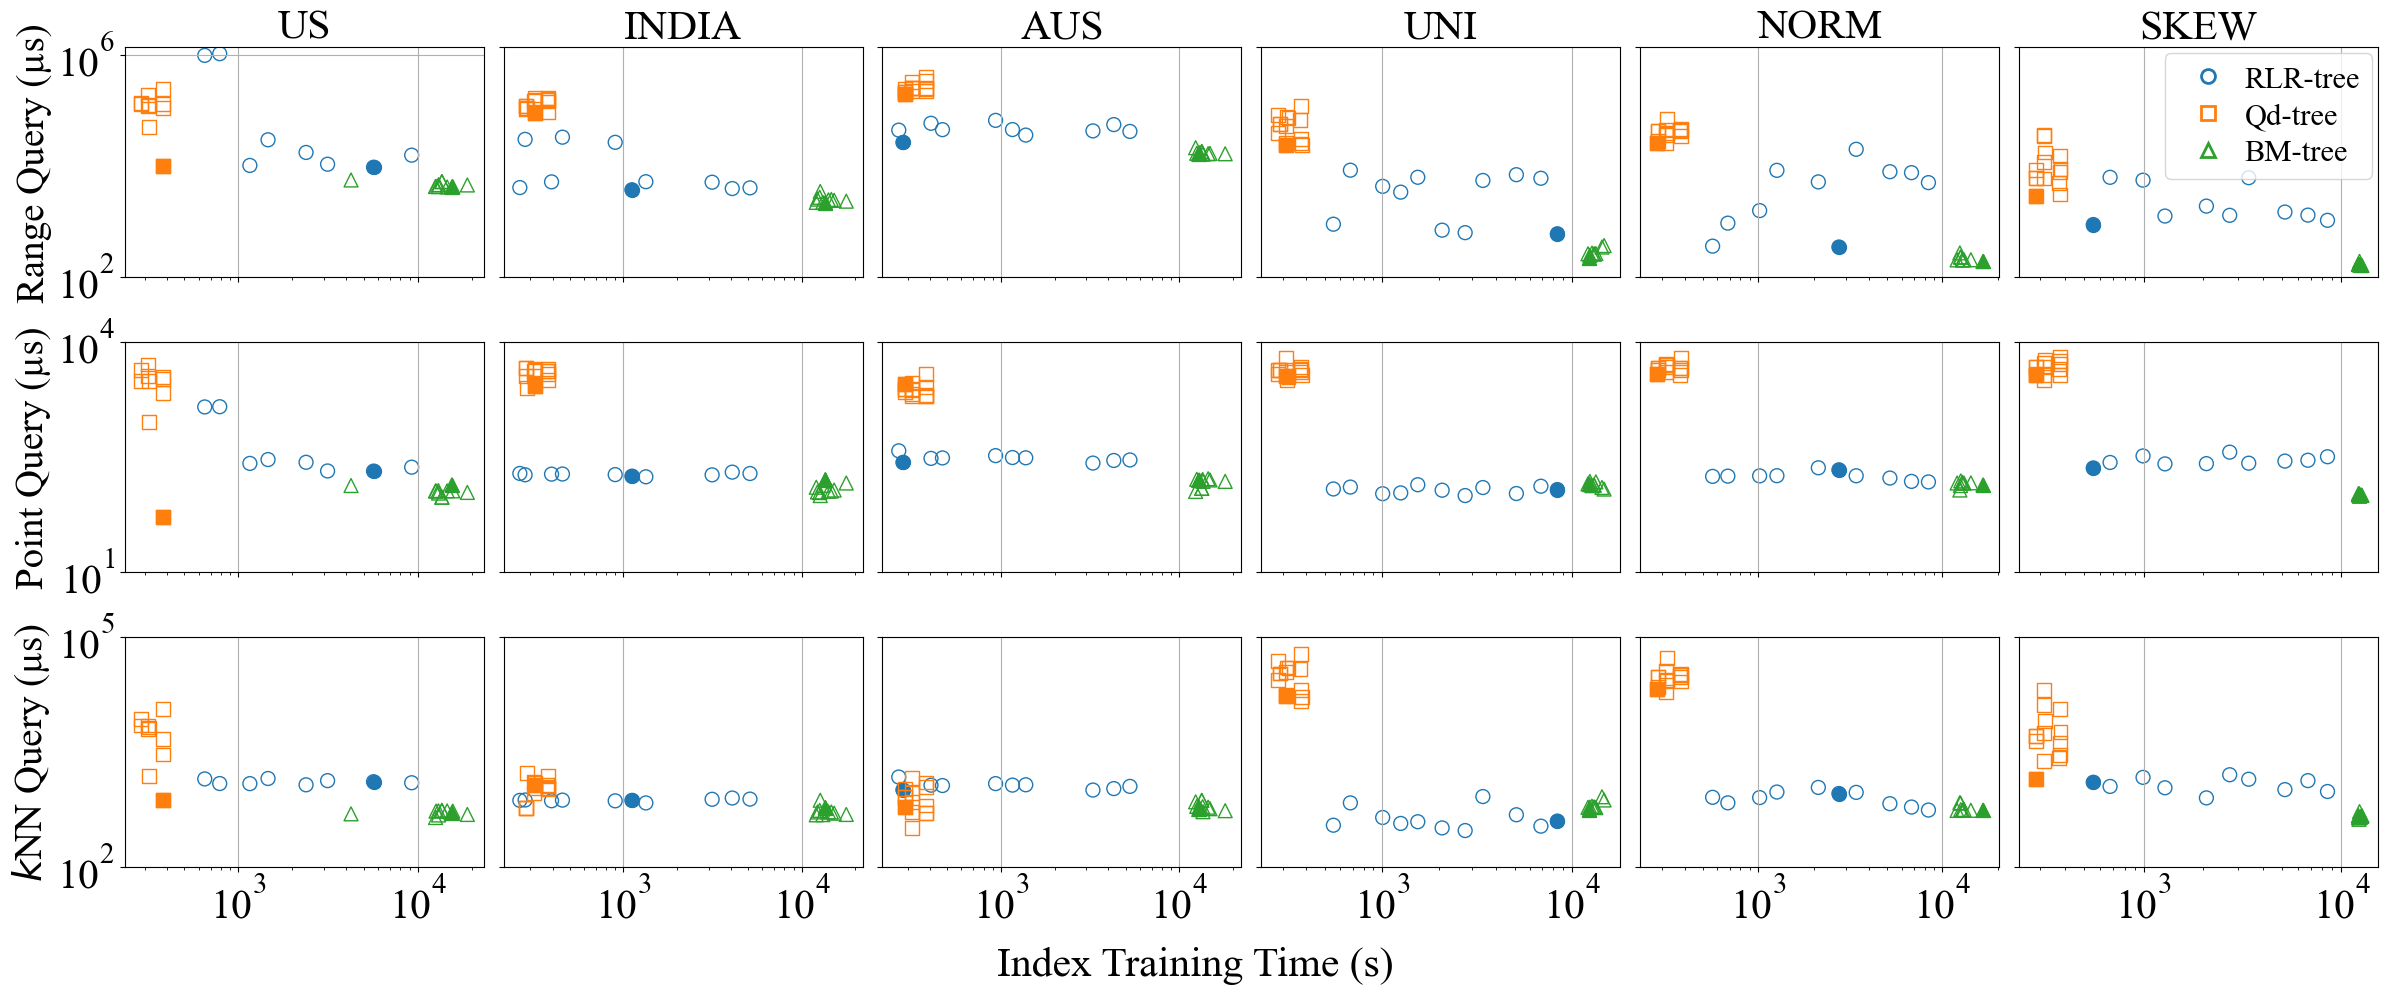

In [6]:
sampled_sizes = [1e4, 2 * 1e4, 4 * 1e4, 8 * 1e4, 16 * 1e4, 32 * 1e4, 64 * 1e4, 128 * 1e4]
query_types = ["Range Query", "Point Query", "$k$NN Query"]
fig, axes = plt.subplots(3, 6, figsize=(24, 10))  # 3 rows for queries, 6 columns for datasets

ranges=[[1e2, 1e6], [1e1, 1e4], [1e2, 1e5]]

for i, query_type in enumerate(query_types):
    for j, dataset in enumerate(display_data_names):
        # Set the correct query data based on the query type
        if query_type == "Point Query":
            query_data = point_query[j]
        elif query_type == "Range Query":
            query_data = range_query[j]
        elif query_type == "$k$NN Query":
            query_data = knn_query[j]

        build_time_dataset = build_time[j]

        best_build = []
        best_query = []
        indices = best_models[dataset]
        for baseline in baselines:
            point_time, range_time, knn_time, build_t = indices[baseline]['metrics']
            best_build.append([build_t])
            if query_type == "Point Query":
                best_query.append([point_time])
            elif query_type == "Range Query":
                best_query.append([range_time])                
            elif query_type == "$k$NN Query":
                best_query.append([knn_time])      

        plot_scatter(sampled_sizes, display_baselines, build_time_dataset, query_data, best_build, best_query, ax=axes[i, j], 
                     # x_label="" if i != 2 else "Index Training Time (s)",  # X label only for bottom row
                     x_label="",  # X label only for bottom row
                     y_label=f"{query_type} (µs)" if j == 0 else "",  # Y label only for left-most column
                     yticks=ranges[i],
                     title=display_data_names[j] if i == 0 else "",  # Title only for the top row (datasets)
                     is_log=True, show_legend=(i==0 and j == 5),
                     is_x_ticks=i==2,
                     is_y_ticks=j==0
                    ) #(i==0 and j == 0) # Disable the legend inside the subplots
        if dataset == "US" and query_type == "Point Query":
            print(best_build, best_query)

fig.supxlabel("Index Training Time (s)", fontsize=30) 
plt.tight_layout()
output_file_paths = [folder + "/exp_sigmod/all_query_time_build_time.pdf", "../figs/exp_sigmod/all_query_time_build_time.png"]
if output_file_paths:
    for output_file_path in output_file_paths:
        if output_file_path.endswith(".pdf"):
            plt.savefig(output_file_path, format='pdf', bbox_inches='tight')
        if output_file_path.endswith(".png"):
            plt.savefig(output_file_path, format='png', bbox_inches='tight')
plt.show()

In [7]:
best_models = {}
is_save = True

# Iterate over each dataset
for dataset_name, indices in dataset_performance_IO.items():
    best_models[dataset_name] = {}
    
    # Iterate over each index in the dataset
    for index_name, models in indices.items():
        best_model = None
        best_score = float('inf')  # Initialize best score to infinity for comparison
        best_tuple = None
        
        # Iterate over each model for the index
        for model_name, query_IO_set in models.items():
            # Get the tuple of query times; assuming one tuple per model_name
            point_IO, range_IO, knn_IO, build_t = next(iter(query_IO_set))

            if point_IO == 0 or range_IO == 0 or knn_IO == 0 or build_t == 0:
                continue
            
            # Calculate the average query time score (ignoring build time for the selection criterion)
            # average_query_score = (point_IO + range_IO + knn_IO) / 3
            average_query_score = calculate_average_query_score(point_IO, range_IO, knn_IO)
            

            
            # Update best model if this model has a lower average score
            if average_query_score < best_score:
                best_score = average_query_score
                best_model = model_name
                best_tuple = (point_IO, range_IO, knn_IO, build_t)
        
        # Store the best model and its performance metrics for the current index in the current dataset
        best_models[dataset_name][index_name] = {
            'model': best_model,
            'metrics': best_tuple  # Store the tuple (point, range, knn, build)
        }

# Display the best model selection and corresponding metrics for each dataset and index
# for dataset, indices in best_models.items():
#     print(f"Dataset: {dataset}")
#     for index, info in indices.items():
#         model = info['model']
#         metrics = info['metrics']
#         print(f"  Index: {index}, Best Model: {model}, Metrics (Point, Range, KNN, Build): {metrics}")

if is_save:
    output_dict = {}
    # Populate the output dictionary with the desired structure
    for dataset, indices in best_models.items():
        output_dict[dataset] = {}
        for index, info in indices.items():
            model = info['model']
            output_dict[dataset][index] = model
    
    with open("best_models_grid_search_IO.json", "w") as json_file:
        json.dump(output_dict, json_file, indent=4)

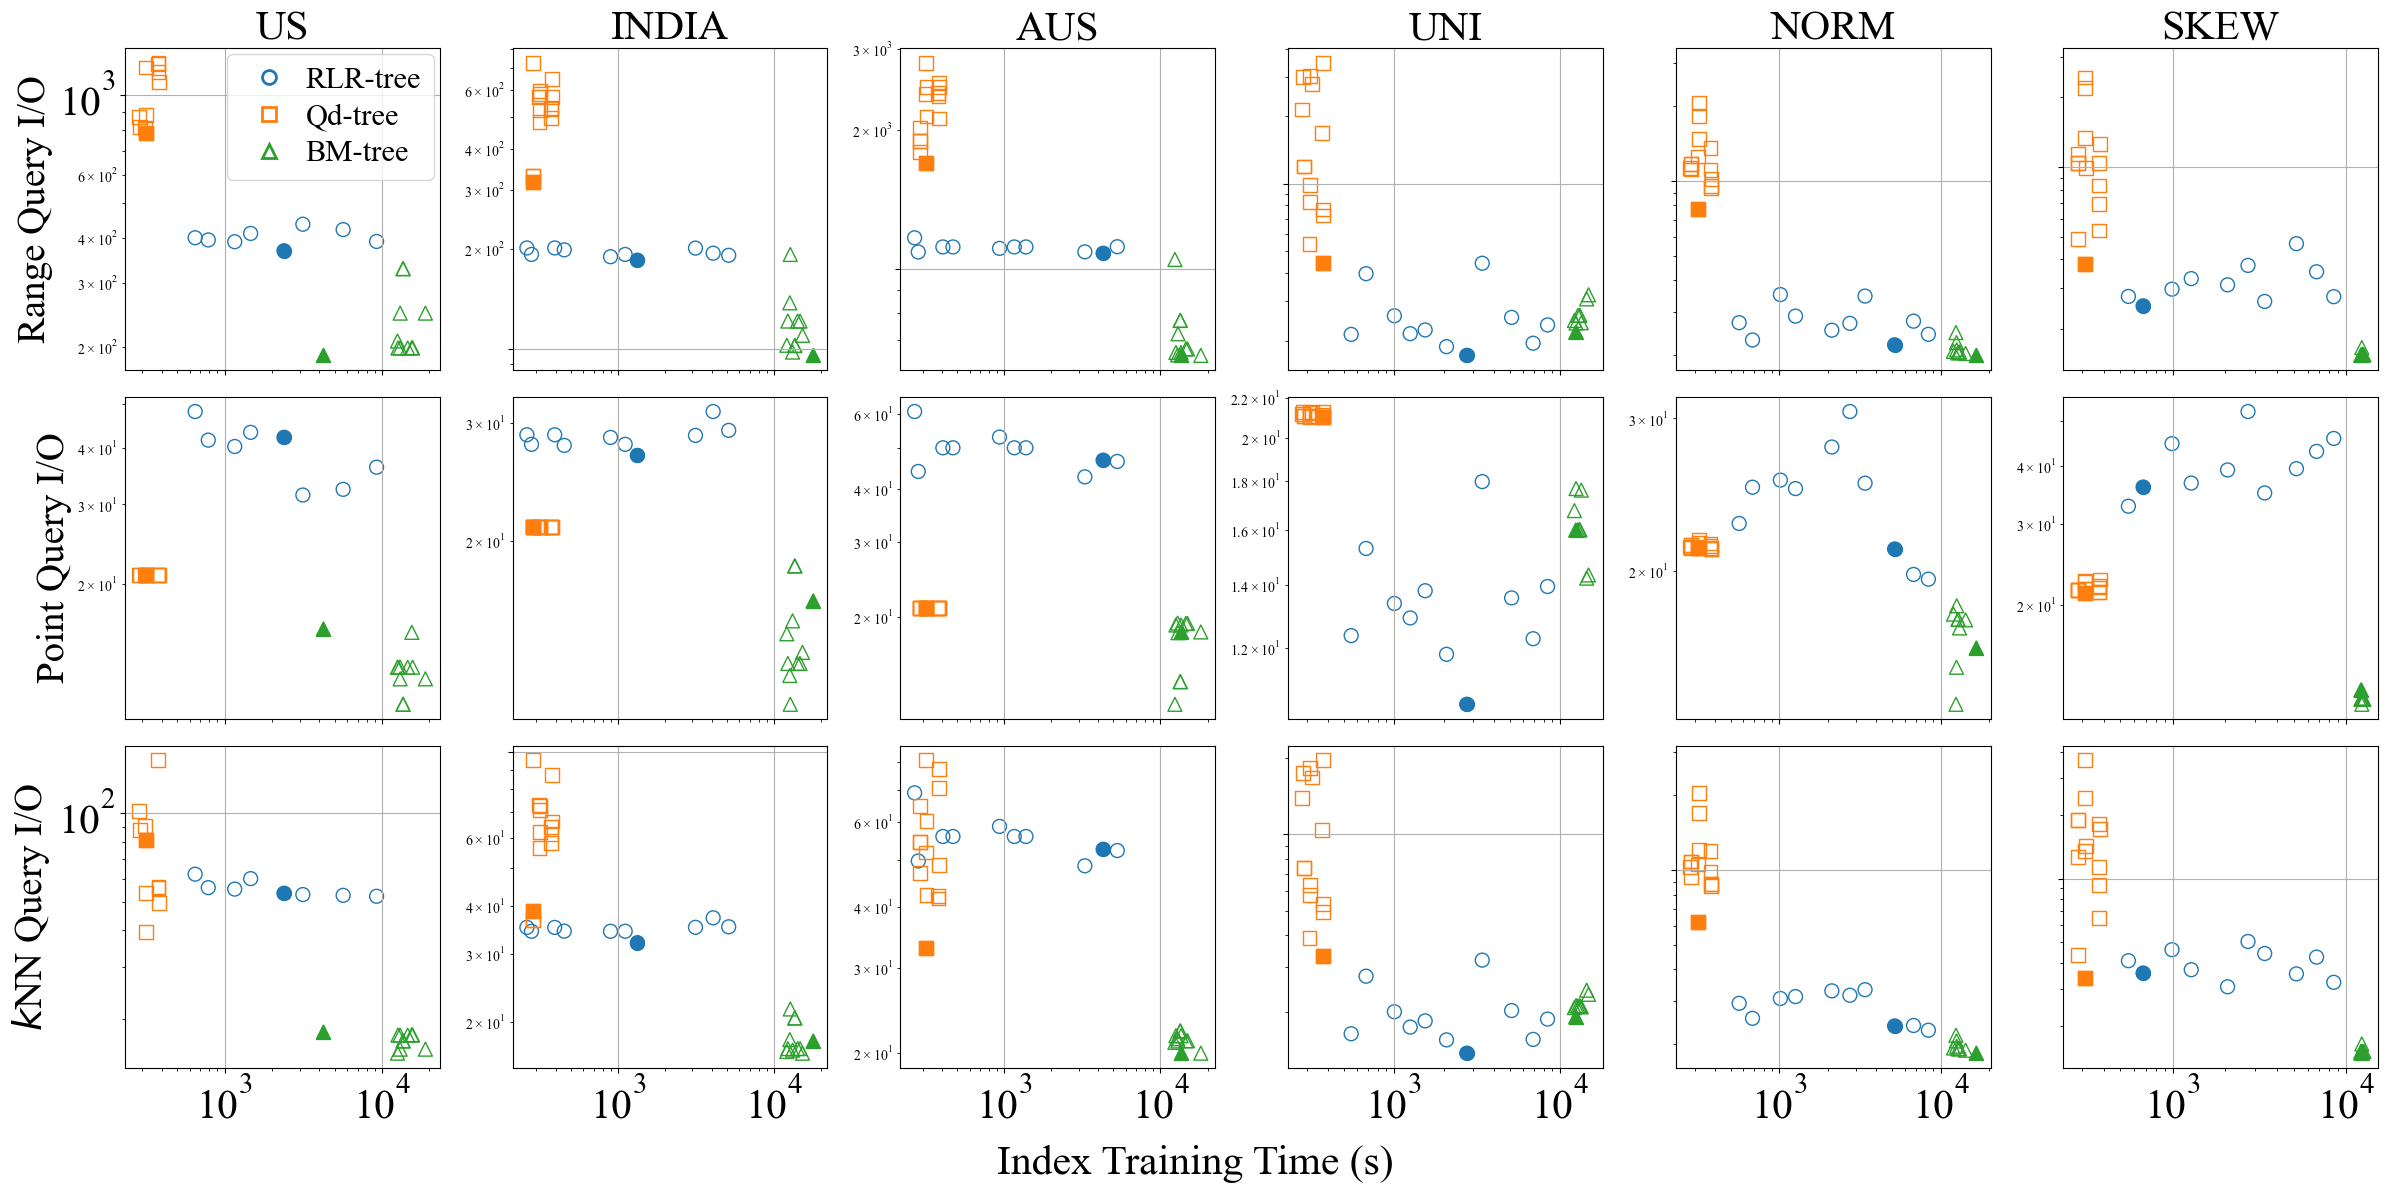

In [8]:
sampled_sizes = [1e4, 2 * 1e4, 4 * 1e4, 8 * 1e4, 16 * 1e4, 32 * 1e4, 64 * 1e4, 128 * 1e4]
query_types = ["Range Query", "Point Query", "$k$NN Query"]
display_data_names = ["US", "INDIA", "AUS", "UNI", "NORM",  "SKEW"]
fig, axes = plt.subplots(3, 6, figsize=(24, 12))  # 3 rows for queries, 6 columns for datasets

for i, query_type in enumerate(query_types):
    
    for j, dataset in enumerate(display_data_names):
        # Set the correct query data based on the query type
        if query_type == "Point Query":
            query_data = point_query_IO[j]
        elif query_type == "Range Query":
            query_data = range_query_IO[j]
        elif query_type == "$k$NN Query":
            query_data = knn_query_IO[j]

        build_time_dataset = build_time[j]

        # if dataset == "US" and query_type == "Point Query":
        #     print(query_data[0])
        #     print(build_time_dataset[0])

        best_build = []
        best_query = []
        indices = best_models[dataset]
        for baseline in baselines:
            point_IO, range_IO, knn_IO, build_t = indices[baseline]['metrics']
            best_build.append([build_t])
            if query_type == "Point Query":
                best_query.append([point_IO])
            elif query_type == "Range Query":
                best_query.append([range_IO])                
            elif query_type == "$k$NN Query":
                best_query.append([knn_IO])   

        plot_scatter(sampled_sizes, display_baselines, build_time_dataset, query_data, best_build, best_query, ax=axes[i, j], 
                     # x_label="" if i != 2 else "Index Training Time (s)",  # X label only for bottom row
                     x_label="",  # X label only for bottom row
                     y_label=f"{query_type} I/O" if j == 0 else "",  # Y label only for left-most column
                     title=display_data_names[j] if i == 0 else "",  # Title only for the top row (datasets)
                     is_log=True, show_legend=(i==0 and j == 0),
                     is_x_ticks=i==2,
                     is_y_ticks=j==0
                    ) #(i==0 and j == 0) # Disable the legend inside the subplots


        # plot_scatter(sampled_sizes, display_baselines, build_time_dataset, query_data, best_build, best_query, ax=axes[i, j], 
        #              # x_label="" if i != 2 else "Index Training Time (s)",  # X label only for bottom row
        #              x_label="",  # X label only for bottom row
        #              y_label=f"{query_type} (µs)" if j == 0 else "",  # Y label only for left-most column
        #              yticks=ranges[i],
        #              title=display_data_names[j] if i == 0 else "",  # Title only for the top row (datasets)
        #              is_log=True, show_legend=(i==0 and j == 5),
        #              is_x_ticks=i==2,
        #              is_y_ticks=j==0
        #             ) #(i==0 and j == 0) # Disable the legend inside the subplots
        # if dataset == "US" and query_type == "Point Query":
        #     print(best_build, best_query)



        # if dataset == "US" and query_type == "Point Query":
        #     print(best_build, best_query)
fig.supxlabel("Index Training Time (s)", fontsize=30) 

plt.tight_layout()
output_file_paths = [folder + "/exp_sigmod/all_query_time_build_time_IO.pdf", "../figs/exp_sigmod/all_query_time_build_time_IO.png"]
if output_file_paths:
    for output_file_path in output_file_paths:
        if output_file_path.endswith(".pdf"):
            plt.savefig(output_file_path, format='pdf', bbox_inches='tight')
        if output_file_path.endswith(".png"):
            plt.savefig(output_file_path, format='png', bbox_inches='tight')

plt.show()